## Crawl data from Binance

In [1]:
import requests
import pandas as pd
import time

def get_binance_data(symbol, interval, start_str, end_str):
    url = "https://api.binance.com/api/v3/klines"
    
    start_ts = int(pd.to_datetime(start_str).timestamp() * 1000)
    end_ts = int(pd.to_datetime(end_str).timestamp() * 1000)
    
    all_data = []
    
    while start_ts < end_ts:
        params = {
            "symbol": symbol,
            "interval": interval,
            "startTime": start_ts,
            "endTime": end_ts,
            "limit": 1000
        }
        
        data = requests.get(url, params=params).json()
        
        if not data:
            break
        
        all_data.extend(data)
        start_ts = data[-1][0] + 1
        time.sleep(0.3)
    
    df = pd.DataFrame(all_data, columns=[
        "open_time","open","high","low","close","volume",
        "close_time","quote_asset_volume","number_of_trades",
        "taker_buy_base","taker_buy_quote","ignore"
    ])
    
    df["open_time"] = pd.to_datetime(df["open_time"], unit='ms')
    
    for col in ["open","high","low","close","volume"]:
        df[col] = df[col].astype(float)
    
    return df

In [2]:
btc = get_binance_data("BTCUSDT", "1d", "2017-01-01", "2026-03-31")

In [3]:
print("BTC shape:", btc.shape)

BTC shape: (3149, 12)


## Clean BTC

In [4]:
btc.head()

,open_time,open,high,low,close,volume,close_time,quote_asset_volume,number_of_trades,taker_buy_base,taker_buy_quote,ignore
0,2017-08-17,4261.48,4485.39,4200.74,4285.08,795.150377,1503014399999,3454770.05073206,3427,616.24854100,2678216.40060401,0
1,2017-08-18,4285.08,4371.52,3938.77,4108.37,1199.888264,1503100799999,5086958.30617151,5233,972.86871000,4129123.31651808,0
2,2017-08-19,4108.37,4184.69,3850.00,4139.98,381.309763,1503187199999,1549483.73542151,2153,274.33604200,1118001.87008735,0
3,2017-08-20,4120.98,4211.08,4032.62,4086.29,467.083022,1503273599999,1930364.39032646,2321,376.79594700,1557401.33373730,0
4,2017-08-21,4069.13,4119.62,3911.79,4016.00,691.743060,1503359999999,2797231.71402728,3972,557.35610700,2255662.55315837,0


In [5]:
btc.tail()

,open_time,open,high,low,close,volume,close_time,quote_asset_volume,number_of_trades,taker_buy_base,taker_buy_quote,ignore
3144,2026-03-27,68820.31,69179.05,65548.25,66407.28,28603.69557,1774655999999,1917318222.70991300,4159306,14568.62853000,976680026.26568100,0
3145,2026-03-28,66407.28,67288.94,65932.09,66377.03,11462.39847,1774742399999,762676255.44706050,1687368,5753.04124000,382921412.22384880,0
3146,2026-03-29,66377.04,67130.50,65000.00,66010.93,10052.85584,1774828799999,667003517.60598700,2146177,4769.42832000,316674097.35018690,0
3147,2026-03-30,66010.93,68169.65,65800.59,66797.37,18353.38975,1774915199999,1234617690.89207520,3902849,9155.91893000,615747978.85138090,0
3148,2026-03-31,66797.38,68589.49,65998.05,68284.48,22105.40662,1775001599999,1490168487.45487460,4846820,10726.18262000,723378692.76676190,0


In [6]:
btc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3149 entries, 0 to 3148
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   open_time           3149 non-null   datetime64[ns]
 1   open                3149 non-null   float64       
 2   high                3149 non-null   float64       
 3   low                 3149 non-null   float64       
 4   close               3149 non-null   float64       
 5   volume              3149 non-null   float64       
 6   close_time          3149 non-null   int64         
 7   quote_asset_volume  3149 non-null   object        
 8   number_of_trades    3149 non-null   int64         
 9   taker_buy_base      3149 non-null   object        
 10  taker_buy_quote     3149 non-null   object        
 11  ignore              3149 non-null   object        
dtypes: datetime64[ns](1), float64(5), int64(2), object(4)
memory usage: 295.3+ KB


In [7]:
btc.describe()

,open_time,open,high,low,close,volume,close_time,number_of_trades
count,3149,3149.000000,3149.000000,3149.000000,3149.000000,3149.000000,3.149000e+03,3.149000e+03
mean,2021-12-08 00:00:00,37070.241362,37855.692509,36217.832369,37090.618514,61359.822125,1.639008e+12,1.960303e+06
min,2017-08-17 00:00:00,3188.010000,3276.500000,2817.000000,3189.020000,228.108068,1.503014e+12,2.153000e+03
25%,2019-10-13 00:00:00,9232.420000,9409.840000,9037.940000,9234.030000,23515.204050,1.571011e+12,4.234460e+05
50%,2021-12-08 00:00:00,26880.260000,27350.000000,26551.000000,26906.960000,38834.287935,1.639008e+12,1.171460e+06
75%,2024-02-03 00:00:00,58427.350000,59809.650000,57098.620000,58622.020000,64703.958740,1.707005e+12,2.489931e+06
max,2026-03-31 00:00:00,124658.540000,126199.630000,123084.000000,124658.540000,760705.362783,1.775002e+12,1.536401e+07
std,NaN,32396.603831,32917.391801,31832.138723,32396.092131,76086.997187,7.855339e+10,2.255341e+06


In [8]:
# Convert object → numeric
cols = ['quote_asset_volume', 'taker_buy_base', 'taker_buy_quote']
for col in cols:
    btc[col] = pd.to_numeric(btc[col], errors='coerce')

# Drop unnecessary column 'ignore'
btc = btc.drop(columns=['ignore', 'close_time'])

# sort + index
btc = btc.sort_values('open_time')
btc = btc.set_index('open_time')

In [9]:
# Check again
btc.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3149 entries, 2017-08-17 to 2026-03-31
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   open                3149 non-null   float64
 1   high                3149 non-null   float64
 2   low                 3149 non-null   float64
 3   close               3149 non-null   float64
 4   volume              3149 non-null   float64
 5   quote_asset_volume  3149 non-null   float64
 6   number_of_trades    3149 non-null   int64  
 7   taker_buy_base      3149 non-null   float64
 8   taker_buy_quote     3149 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 246.0 KB


In [10]:
# Check missing values
btc.isnull().sum()

open                  0
high                  0
low                   0
close                 0
volume                0
quote_asset_volume    0
number_of_trades      0
taker_buy_base        0
taker_buy_quote       0
dtype: int64

In [11]:
# Check null values
btc.index.duplicated().sum()

0

In [12]:
# Check missing day
btc.index.to_series().diff().value_counts()

open_time
1 days    3148
Name: count, dtype: int64

In [13]:
# Check consistancy between high, low and open/close column
print((btc['high'] < btc[['open','close']].max(axis=1)).sum())
print((btc['low'] > btc[['open','close']].min(axis=1)).sum())
# Check low and high price
print((btc['low'] > btc['high']).sum())

0
0
0


In [14]:
# Check negative price
(btc[['open','high','low','close']] < 0).sum()

open     0
high     0
low      0
close    0
dtype: int64

In [15]:
# Check volume = 0
(btc['volume'] == 0).sum()

0

In [16]:
# Check timezone (for merging others data)
print(btc.index.tz)

None


In [17]:
# Set UTC timezone for btc
btc.index = btc.index.tz_localize('UTC')
# Check timezone again
print(btc.index.tz)

UTC


In [18]:
btc.to_csv("btc_dataset.csv")

In [19]:
import numpy as np
# Check outliers
# Tính Log Return
btc['return'] = np.log(btc['close'] / btc['close'].shift(1))

# Lấp chỗ trống NaN bằng số 0
btc['return'] = btc['return'].fillna(0)

# Top pump
top_up = btc['return'].sort_values(ascending=False).head(5)

# Top dump
top_down = btc['return'].sort_values().head(5)

# Top fluctuate
top_vol = btc['return'].abs().sort_values(ascending=False).head(5)

print(top_up)
print(top_down)
print(top_vol)

open_time
2017-12-07 00:00:00+00:00    0.202952
2021-02-08 00:00:00+00:00    0.178449
2019-04-02 00:00:00+00:00    0.158684
2019-10-25 00:00:00+00:00    0.154984
2020-03-13 00:00:00+00:00    0.150322
Name: return, dtype: float64
open_time
2020-03-12 00:00:00+00:00   -0.502607
2018-01-16 00:00:00+00:00   -0.216880
2017-09-14 00:00:00+00:00   -0.212657
2022-06-13 00:00:00+00:00   -0.166998
2018-02-05 00:00:00+00:00   -0.164980
Name: return, dtype: float64
open_time
2020-03-12 00:00:00+00:00    0.502607
2018-01-16 00:00:00+00:00    0.216880
2017-09-14 00:00:00+00:00    0.212657
2017-12-07 00:00:00+00:00    0.202952
2021-02-08 00:00:00+00:00    0.178449
Name: return, dtype: float64


On March 12, 2020, BTC experienced a sharp decline of approximately 40% in a single day. This corresponds to the "Black Thursday" event during the COVID-19 market crash. Therefore, this extreme value reflects a real market shock rather than a data error or false outlier.

In [20]:
btc.to_csv("btc_dataset.csv")

In [21]:
import requests
import pandas as pd
import time
from pytrends.request import TrendReq

# ==========================================
# 1. CÀO BINANCE FUNDING RATE (Lịch sử)
# ==========================================
def fetch_binance_funding_rate(symbol="BTCUSDT"):
    print(f"⏳ Đang tải Funding Rate cho {symbol}...")
    url = "https://fapi.binance.com/fapi/v1/fundingRate"
    limit = 1000
    
    # 👈 SỬA Ở ĐÂY: Dùng timestamp mili-giây của tháng 9/2019 thay vì 0
    start_time = 1567990400000  
    all_data = []

    while True:
        params = {'symbol': symbol, 'limit': limit, 'startTime': start_time}
        response = requests.get(url, params=params)
        data = response.json()
        
        if not data:
            break
            
        all_data.extend(data)
        
        # Lấy mốc thời gian của dòng cuối cùng cộng thêm 1ms để cào trang tiếp theo
        start_time = data[-1]['fundingTime'] + 1
        
        # Nếu trả về ít hơn 1000 nghĩa là đã cào chạm đến thời điểm hiện tại
        if len(data) < limit:
            break
            
        time.sleep(0.5) # Nghỉ nửa giây tránh bị Binance block IP

    df = pd.DataFrame(all_data)
    df['datetime'] = pd.to_datetime(df['fundingTime'], unit='ms')
    df.set_index('datetime', inplace=True)
    df['funding_rate'] = df['fundingRate'].astype(float)
    
    # Binance trả funding 8 tiếng/lần. Tính trung bình để gộp thành 1 ngày (1D)
    df_daily = df[['funding_rate']].resample('D').mean()
    print("✅ Đã tải xong Funding Rate chuẩn lịch sử!")
    return df_daily

# ==========================================
# 2. CÀO CRYPTO FEAR & GREED INDEX
# ==========================================
def fetch_fear_and_greed():
    print("⏳ Đang tải Fear & Greed Index...")
    url = "https://api.alternative.me/fng/?limit=0" # limit=0 là lấy tất cả
    response = requests.get(url)
    data = response.json()['data']
    
    df = pd.DataFrame(data)
    df['datetime'] = pd.to_datetime(df['timestamp'], unit='s')
    df.set_index('datetime', inplace=True)
    df['fng_value'] = df['value'].astype(float)
    
    # Chuẩn hóa về index khung ngày
    df_daily = df[['fng_value']].resample('D').mean()
    print("✅ Đã tải xong Fear & Greed Index!")
    return df_daily

# ==========================================
# 3. CÀO GOOGLE TRENDS (Độ FOMO của Retailer)
# ==========================================
def fetch_google_trends(keyword="Bitcoin"):
    print(f"⏳ Đang tải Google Trends cho từ khóa '{keyword}' từ 2017...")
    try:
        pytrends = TrendReq(hl='en-US', tz=360)
        
        # SỬA Ở ĐÂY: Ép lấy từ 2017-08-01 đến ngày hiện tại (2026)
        # Google Trends sẽ tự động nhóm dữ liệu theo Tuần (Weekly) cho khoảng thời gian dài này.
        pytrends.build_payload([keyword], cat=0, timeframe='2017-08-01 2026-04-19', geo='', gprop='')
        df = pytrends.interest_over_time()
        
        if df.empty:
            print("⚠️ Google Trends không trả về dữ liệu.")
            return pd.DataFrame()
            
        df.rename(columns={keyword: 'google_trend_score'}, inplace=True)
        
        df_daily = df[['google_trend_score']].resample('D').ffill()
        
        print("✅ Đã tải xong Google Trends Full Lịch Sử!")
        return df_daily
    except Exception as e:
        print(f"❌ Lỗi khi lấy Google Trends: {e}")
        return pd.DataFrame()

# ==========================================
# GỘP TẤT CẢ VÀO FILE BTC GỐC CỦA MÀY
# ==========================================
def merge_sentiment_features(btc_df):
    """
    btc_df: DataFrame giá gốc của mày, yêu cầu phải có Index là Datetime (khung 1 ngày)
    """
    # 1. Lấy data
    df_funding = fetch_binance_funding_rate()
    df_fng = fetch_fear_and_greed()
    df_trends = fetch_google_trends(keyword="Bitcoin")
    
    # 2. Xóa timezone nếu có để tránh lỗi khi merge
    btc_df.index = btc_df.index.tz_localize(None)
    df_funding.index = df_funding.index.tz_localize(None)
    df_fng.index = df_fng.index.tz_localize(None)
    if not df_trends.empty:
        df_trends.index = df_trends.index.tz_localize(None)

    # 3. Nối (Join) vào bảng giá btc. Dùng left join để giữ nguyên số ngày của btc
    print("\n🔗 Đang gộp dữ liệu vào bảng chính...")
    btc_merged = btc_df.copy()
    btc_merged = btc_merged.join(df_funding, how='left')
    btc_merged = btc_merged.join(df_fng, how='left')
    if not df_trends.empty:
        btc_merged = btc_merged.join(df_trends, how='left')
    
    # 4. Lấp lỗ hổng dữ liệu (Fill NA)
    # Vì API đôi khi mất kết nối 1-2 ngày, ta điền dữ liệu của ngày hôm trước lên (ffill)
    btc_merged['funding_rate'] = btc_merged['funding_rate'].ffill().fillna(0)
    btc_merged['fng_value'] = btc_merged['fng_value'].ffill().fillna(50)
    if 'google_trend_score' in btc_merged.columns:
        btc_merged['google_trend_score'] = btc_merged['google_trend_score'].ffill().fillna(0)
        
    print("🎉 Hoàn tất! Bảng dữ liệu đã có thêm vũ khí tâm lý.")
    return btc_merged

# --- CÁCH SỬ DỤNG TRONG THỰC TẾ ---
# Giả sử mày đang có biến `btc` là dataframe giá đã load từ file CSV
# btc = pd.read_csv('btc_1d.csv', index_col='datetime', parse_dates=True)
btc_full = merge_sentiment_features(btc)
print(btc_full[['close', 'funding_rate', 'fng_value', 'google_trend_score']].tail())

⏳ Đang tải Funding Rate cho BTCUSDT...
✅ Đã tải xong Funding Rate chuẩn lịch sử!
⏳ Đang tải Fear & Greed Index...


C:\Users\TRITON\AppData\Local\Temp\ipykernel_12772\2992504246.py:57: FutureWarning: The behavior of 'to_datetime' with 'unit' when parsing strings is deprecated. In a future version, strings will be parsed as datetime strings, matching the behavior without a 'unit'. To retain the old behavior, explicitly cast ints or floats to numeric type before calling to_datetime.
  df['datetime'] = pd.to_datetime(df['timestamp'], unit='s')


✅ Đã tải xong Fear & Greed Index!
⏳ Đang tải Google Trends cho từ khóa 'Bitcoin' từ 2017...
✅ Đã tải xong Google Trends Full Lịch Sử!

🔗 Đang gộp dữ liệu vào bảng chính...
🎉 Hoàn tất! Bảng dữ liệu đã có thêm vũ khí tâm lý.
               close  funding_rate  fng_value  google_trend_score
open_time                                                        
2026-03-27  66407.28     -0.000031       13.0                  29
2026-03-28  66377.03     -0.000053       12.0                  29
2026-03-29  66010.93     -0.000003        9.0                  29
2026-03-30  66797.37      0.000005        8.0                  29
2026-03-31  68284.48     -0.000015       11.0                  29


In [22]:
print(btc_full[['close', 'funding_rate', 'fng_value', 'google_trend_score']].head())

              close  funding_rate  fng_value  google_trend_score
open_time                                                       
2017-08-17  4285.08           0.0       50.0                  21
2017-08-18  4108.37           0.0       50.0                  21
2017-08-19  4139.98           0.0       50.0                  21
2017-08-20  4086.29           0.0       50.0                  21
2017-08-21  4016.00           0.0       50.0                  21


In [23]:
btc_full.to_csv('btc_full.csv')

## EDA BTC

The dataset consists of 3,059 daily observations of BTC price and trading activity from August 2017 to December 2025. All variables are numeric and there are no missing values, indicating that the dataset is clean and ready for analysis.

The dataset includes price-related variables (open, high, low, close) and market activity variables (volume, quote asset volume, number of trades, taker buy metrics).

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

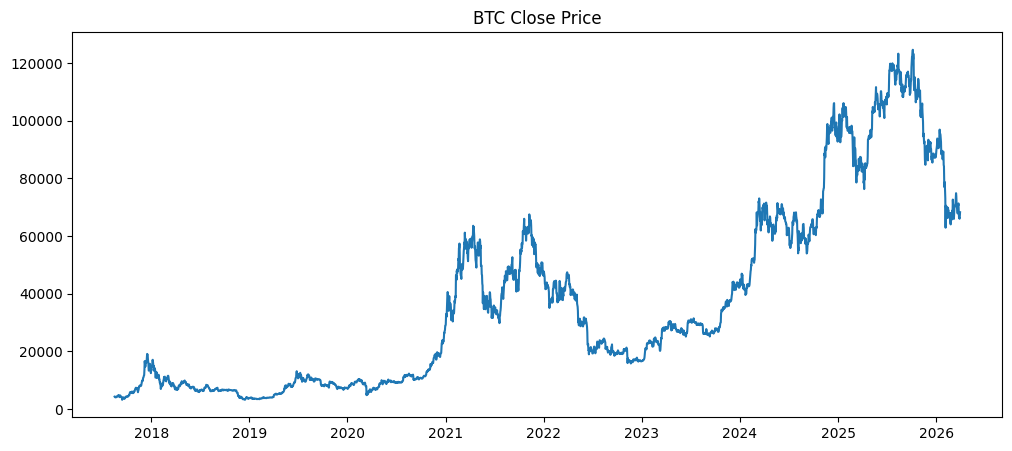

In [25]:
# Price Action
plt.figure(figsize=(12,5))
plt.plot(btc['close'])
plt.title('BTC Close Price')
plt.show()

The BTC price series exhibits strong cyclical behavior characterized by multiple boom-and-bust phases over time. 

From 2017 to early 2018, Bitcoin experienced a rapid bull run followed by a sharp correction, indicating high speculative activity. This was followed by a prolonged consolidation phase during 2018–2019, where the price remained relatively stable at lower levels.

A significant upward trend began in late 2020, leading to a major bull market in 2021, where BTC reached new highs. This period was followed by a substantial decline throughout 2022, reflecting a bear market phase.

From 2023 onwards, Bitcoin gradually recovered and entered another strong uptrend, reaching new all-time highs in 2024–2025. However, recent price movements show increased volatility and signs of short-term corrections.

Overall, the price action demonstrates that Bitcoin is highly volatile and follows clear market cycles, with alternating periods of expansion (bull markets) and contraction (bear markets).

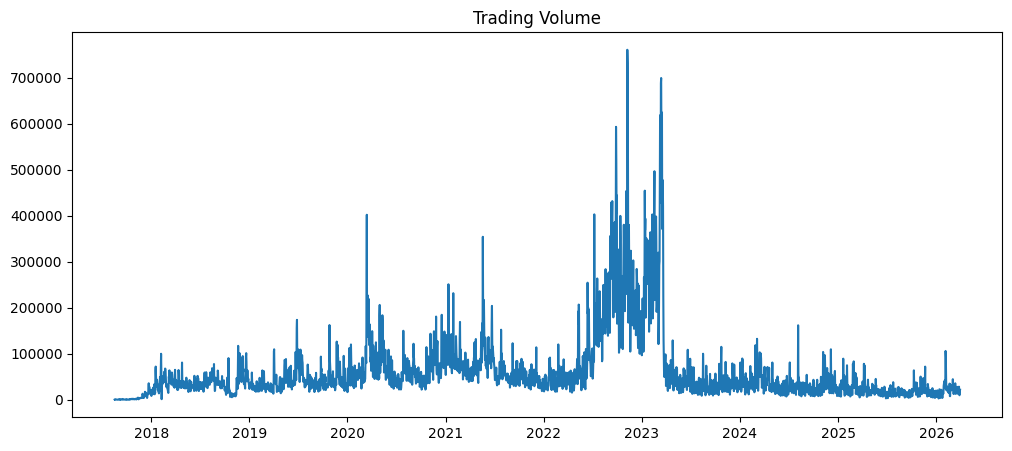

In [26]:
# Trading Volume Analysis
plt.figure(figsize=(12,5))
plt.plot(btc['volume'])
plt.title('Trading Volume')
plt.show()

- Low volume in the early stages → small market.

- Strong increase in volume and high volatility in 2020–2022 → a period of a "hot" and highly volatile market.

- Volume peaks during crash/stress periods, not at price peaks.

- After 2022, volume decreases despite price increases → more stable market, less speculation.

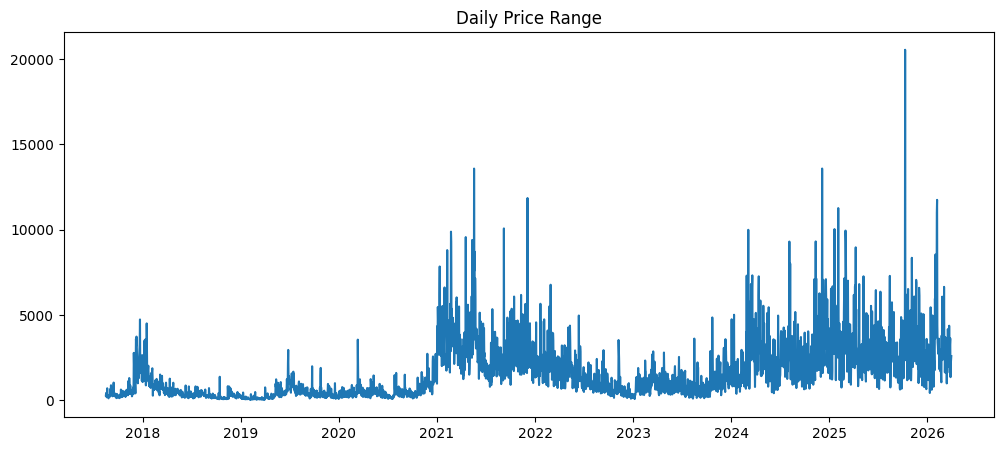

In [27]:
# Price Spread
plt.figure(figsize=(12,5))
plt.plot(btc['high'] - btc['low'])
plt.title('Daily Price Range')
plt.show()

- Low price range in the early stages → small prices.

- Strong increase from 2020 → market expansion.

- Large spike in 2021–2022 → extremely volatile.

- 2024–2025 will still be highly volatile despite decreasing volume.

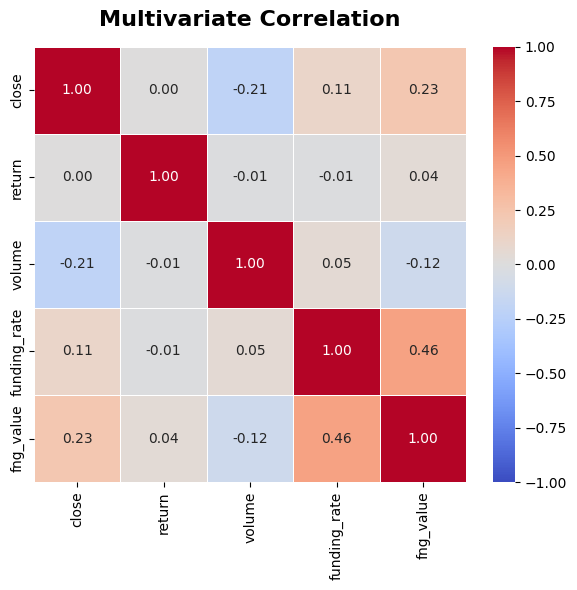

In [28]:
# Heatmap
import matplotlib.pyplot as plt
import seaborn as sns

# Kiểm tra và tính toán cột 'return' nếu mày chưa tính ở bước gộp
if 'return' not in btc_full.columns:
    # Tính pct_change và fillna(0) cho ngày đầu tiên như logic của mày
    btc_full['return'] = btc_full['close'].pct_change().fillna(0)

# Chọn các cột đại diện mang ý nghĩa kinh tế để đưa vào ma trận
cols_to_corr = ['close', 'return', 'volume', 'funding_rate', 'fng_value']

# Lọc lại để chắc chắn các cột này tồn tại trong btc_full
cols_to_corr = [c for c in cols_to_corr if c in btc_full.columns]

# Tính ma trận tương quan Pearson
corr_matrix = btc_full[cols_to_corr].corr(method='pearson')

# Trực quan hóa bằng Heatmap
plt.figure(figsize=(6, 6))
sns.heatmap(corr_matrix, 
            annot=True,              # Hiện số trên từng ô
            cmap='coolwarm',         # Bảng màu nóng-lạnh (xanh-đỏ)
            fmt=".2f",               # Lấy 2 chữ số thập phân
            linewidths=0.5, 
            vmin=-1, vmax=1)         # Giới hạn thang đo từ -1 đến 1

plt.title("Multivariate Correlation", fontsize=16, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

- Returns show near-zero correlation with all variables → weak linear predictability.
- Price is weakly correlated with sentiment indicators.
- Volume is weakly and negatively correlated with price.
- Funding rate is moderately correlated with sentiment.
- Sentiment features are partially correlated with each other.

→ Linear relationships are weak, suggesting the need for feature engineering and nonlinear models.

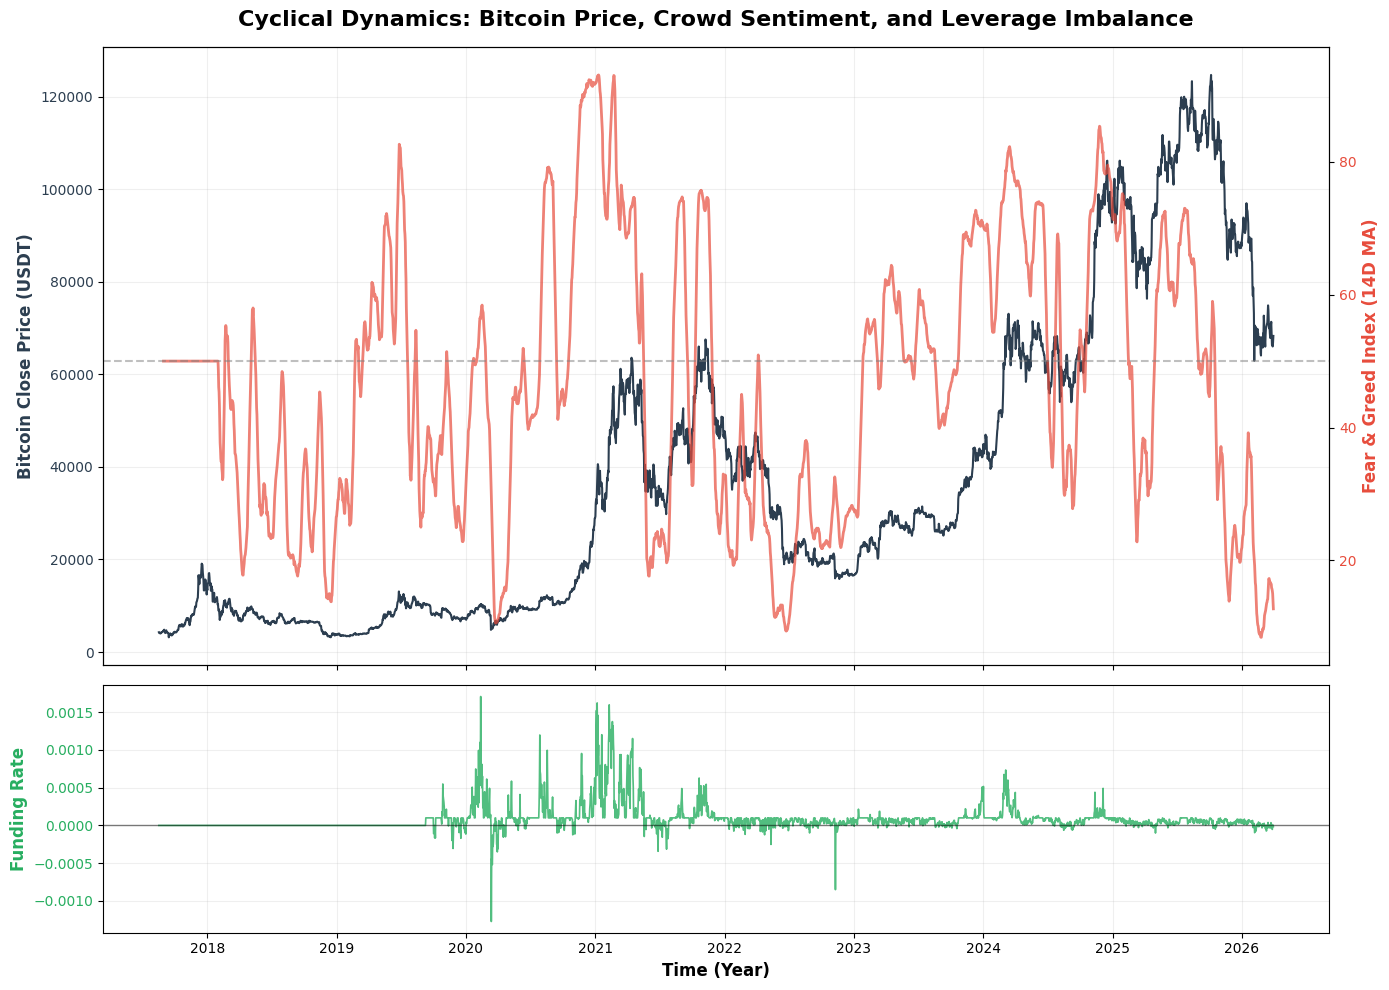

In [29]:
import matplotlib.pyplot as plt

# Tạo 2 biểu đồ (2 rows, 1 column), dùng chung trục X (sharex=True)
# Tỷ lệ chiều cao 2.5 : 1 (Ô trên to, ô dưới nhỏ)
fig, (ax1, ax3) = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [2.5, 1]}, sharex=True)

# ==========================================
# Ô TRÊN (ax1 & ax2): GIÁ BTC VÀ FEAR & GREED
# ==========================================
color1 = '#2c3e50'
ax1.set_ylabel('Bitcoin Close Price (USDT)', color=color1, fontsize=12, fontweight='bold')
ax1.plot(btc_full.index, btc_full['close'], color=color1, linewidth=1.5, label='BTC Close Price')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.grid(alpha=0.2)

ax2 = ax1.twinx()
color2 = '#e74c3c'
ax2.set_ylabel('Fear & Greed Index (14D MA)', color=color2, fontsize=12, fontweight='bold')
ax2.plot(btc_full.index, btc_full['fng_value'].rolling(14).mean(), 
         color=color2, alpha=0.7, linewidth=2, label='FnG (14D MA)')
ax2.axhline(50, color='gray', linestyle='--', alpha=0.5, label='Neutral (50)')
ax2.tick_params(axis='y', labelcolor=color2)

ax1.set_title('Cyclical Dynamics: Bitcoin Price, Crowd Sentiment, and Leverage Imbalance', 
              fontsize=16, fontweight='bold', pad=15)

# ==========================================
# Ô DƯỚI (ax3): FUNDING RATE
# ==========================================
color3 = '#27ae60' # Màu xanh lá cây nhìn cho rõ dòng tiền
ax3.set_xlabel('Time (Year)', fontsize=12, fontweight='bold')
ax3.set_ylabel('Funding Rate', color=color3, fontsize=12, fontweight='bold')

# Vẽ đường Funding Rate
ax3.plot(btc_full.index, btc_full['funding_rate'], color=color3, linewidth=1.2, alpha=0.8)

# Kẻ đường mốc 0 (Zero line) để phân biệt Long/Short trả phí
ax3.axhline(0, color='black', linestyle='-', linewidth=1, alpha=0.5)
ax3.tick_params(axis='y', labelcolor=color3)
ax3.grid(alpha=0.2)

# Tự động căn chỉnh khoảng cách
fig.tight_layout()
plt.show()

- Price follows cyclical boom-and-bust patterns.
- Sentiment peaks near tops and bottoms.
- Funding rate spikes reflect leverage imbalance.
- High funding → crowded longs → potential reversal risk.
- Low funding → crowded shorts → potential rebound.
- Leverage amplifies market volatility and reversals.

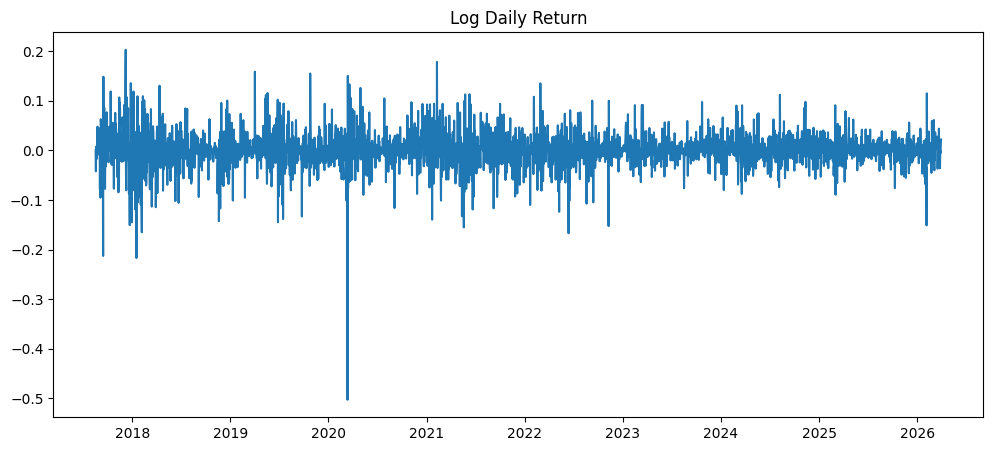

In [30]:
# Log Daily return by time
plt.figure(figsize=(12,5))
plt.plot(btc['return'])
plt.title('Log Daily Return')
plt.show()

- Log returns fluctuate around zero, indicating no persistent short-term directional trend.

- The series exhibits clear volatility clustering, where periods of high volatility are followed by similar periods.

- Extreme spikes are present, including both large positive and negative movements, reflecting sudden market shocks.

- Notably, a significant negative spike (e.g., around early 2020) corresponds to major events such as the COVID-19 crash, confirming that these are real market movements rather than anomalies.

- Volatility appears time-varying, with higher fluctuations in earlier periods and relatively more stable behavior in recent years.

- Overall, the log return series reflects a noisy and high-risk process, characterized by frequent small fluctuations and occasional large shocks.

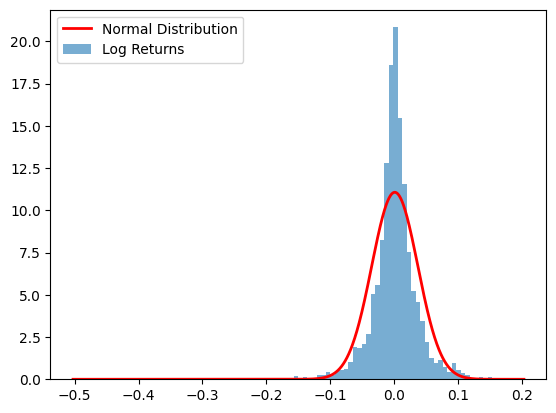

In [31]:
import numpy as np
import scipy.stats as stats

mu = btc['return'].mean()
sigma = btc['return'].std()

x = np.linspace(btc['return'].min(), btc['return'].max(), 1000)
pdf = stats.norm.pdf(x, mu, sigma)

plt.hist(btc['return'], bins=100, density=True, alpha=0.6)
plt.plot(x, pdf, color='red', linewidth=2)
plt.legend(['Normal Distribution', 'Log Returns'])

- Log returns are centered around zero, indicating that most daily price changes fluctuate without a consistent directional bias.

- The distribution is highly concentrated near zero, showing that small price movements dominate the market.

- The distribution appears relatively symmetric, suggesting a balanced occurrence of positive and negative returns.

- However, fat tails are still present, indicating that extreme market movements occur with non-negligible probability.

- The presence of these extreme values reflects the inherent risk and volatility of the cryptocurrency market.

- Overall, the log return distribution suggests a noisy, high-risk process with frequent small fluctuations and occasional large shocks.

## Stationary check

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller, kpss

In [33]:
def adf_test(series, name=""):
    result = adfuller(series.dropna())
    
    print(f"ADF Test - {name}")
    print(f"Test Statistic : {result[0]}")
    print(f"p-value        : {result[1]}")
    print(f"Lags Used      : {result[2]}")
    print(f"N Observations : {result[3]}")
    
    for key, value in result[4].items():
        print(f"Critical Value ({key}) : {value}")
    
    if result[1] < 0.05:
        print("=> Stationary (reject H0)")
    else:
        print("=> Non-stationary (fail to reject H0)")
    
    print("-"*50)

In [34]:
def kpss_test(series, name=""):
    result = kpss(series.dropna(), regression='c', nlags='auto')
    
    print(f"KPSS Test - {name}")
    print(f"Test Statistic : {result[0]}")
    print(f"p-value        : {result[1]}")
    print(f"Lags Used      : {result[2]}")
    
    for key, value in result[3].items():
        print(f"Critical Value ({key}) : {value}")
    
    if result[1] < 0.05:
        print("=> Non-stationary (reject H0)")
    else:
        print("=> Stationary (fail to reject H0)")
    
    print("-"*50)

In [35]:
# Giá (price)
adf_test(btc['close'], "Close Price")
kpss_test(btc['close'], "Close Price")

# Log return
adf_test(btc['return'], "Log Return")
kpss_test(btc['return'], "Log Return")

ADF Test - Close Price
Test Statistic : -1.2402417289973275
p-value        : 0.6560497267554728
Lags Used      : 25
N Observations : 3123
Critical Value (1%) : -3.432445639802861
Critical Value (5%) : -2.8624659237441654
Critical Value (10%) : -2.567262891276225
=> Non-stationary (fail to reject H0)
--------------------------------------------------
KPSS Test - Close Price
Test Statistic : 6.910399348041053
p-value        : 0.01
Lags Used      : 32
Critical Value (10%) : 0.347
Critical Value (5%) : 0.463
Critical Value (2.5%) : 0.574
Critical Value (1%) : 0.739
=> Non-stationary (reject H0)
--------------------------------------------------
ADF Test - Log Return
Test Statistic : -38.99015489863128
p-value        : 0.0
Lags Used      : 1
N Observations : 3147
Critical Value (1%) : -3.432429644737677
Critical Value (5%) : -2.862458859056656
Critical Value (10%) : -2.567259130154472
=> Stationary (reject H0)
--------------------------------------------------
KPSS Test - Log Return
Test St

C:\Users\TRITON\AppData\Local\Temp\ipykernel_12772\747954308.py:2: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  result = kpss(series.dropna(), regression='c', nlags='auto')
C:\Users\TRITON\AppData\Local\Temp\ipykernel_12772\747954308.py:2: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result = kpss(series.dropna(), regression='c', nlags='auto')


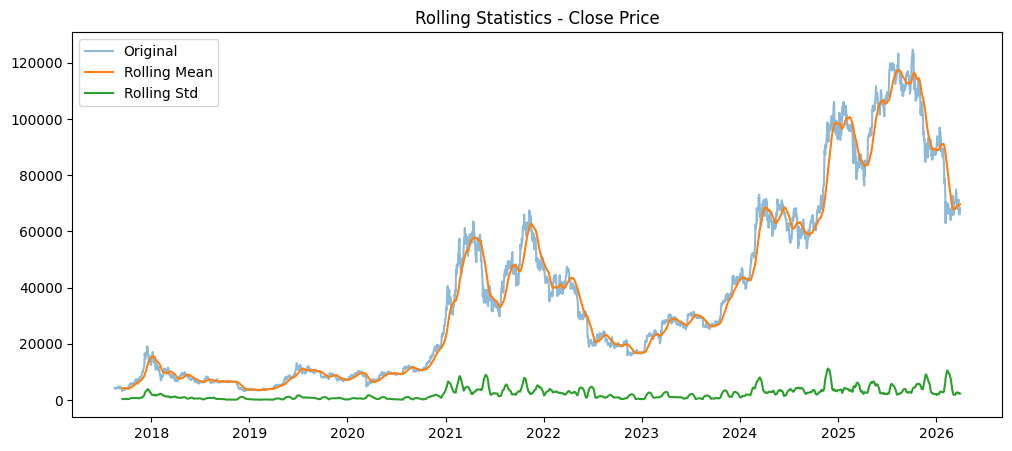

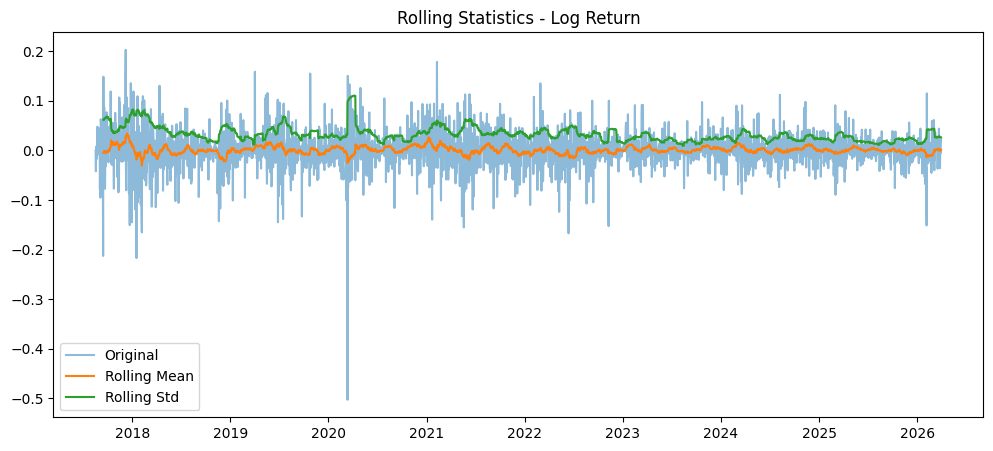

In [36]:
def plot_rolling(series, window=30, name=""):
    rolling_mean = series.rolling(window).mean()
    rolling_std  = series.rolling(window).std()
    
    plt.figure(figsize=(12,5))
    plt.plot(series, label='Original', alpha=0.5)
    plt.plot(rolling_mean, label='Rolling Mean')
    plt.plot(rolling_std, label='Rolling Std')
    
    plt.title(f'Rolling Statistics - {name}')
    plt.legend()
    plt.show()
    
plot_rolling(btc['close'], name="Close Price")
plot_rolling(btc['return'], name="Log Return")

- Close price is non-stationary (ADF fails, KPSS rejects stationarity).

- Log return is stationary (ADF rejects unit root, KPSS supports stationarity).

- Results are consistent across both tests.

- Indicates that transformation is required before modeling.

Summary:

- BTC price exhibits cyclical boom-and-bust patterns and is clearly non-stationary, as confirmed by both statistical tests (ADF, KPSS) and rolling statistics.

- Trading volume reflects market activity and tends to spike during periods of high volatility rather than consistently following price direction.

- Price variables (open, high, low, close) are highly redundant due to near-perfect correlation, and can be reduced to a single representative (e.g., close).

- Trading activity variables are strongly correlated, suggesting overlapping information and potential redundancy.

- Log returns are centered around zero, approximately stationary, and exhibit volatility clustering and fat tails, indicating non-normality and the presence of extreme market movements.

→ Overall, the dataset demonstrates key characteristics of financial time series, including non-stationarity in price, stationarity in returns, heavy-tailed distributions, time-varying volatility, and strong interdependence among variables.

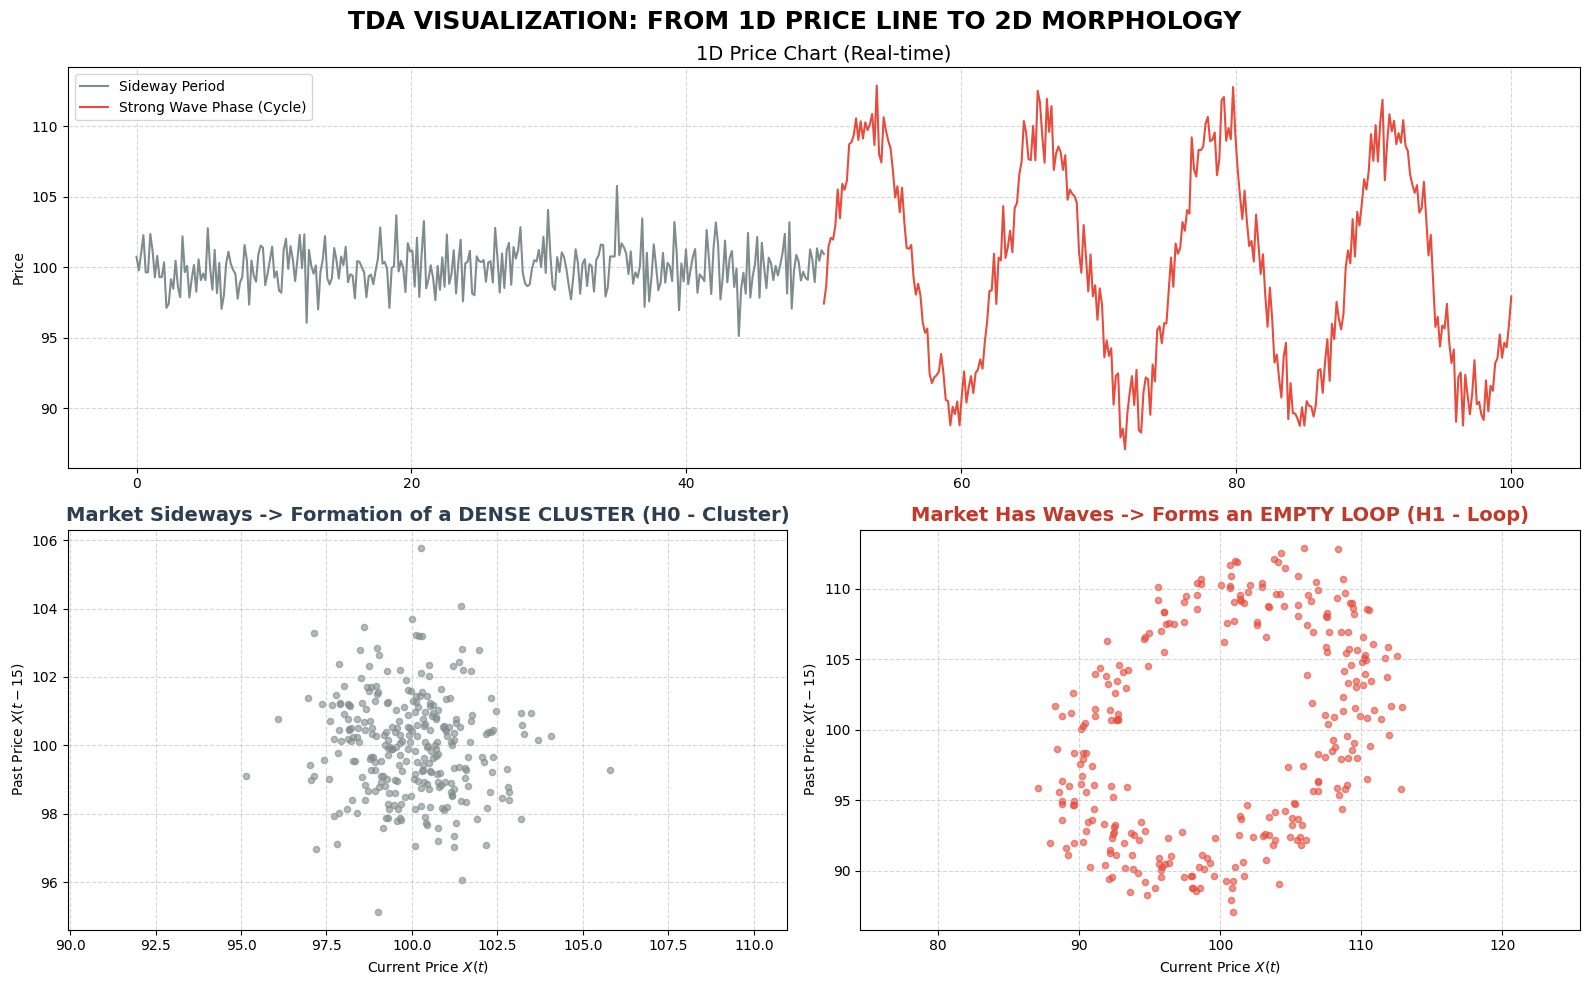

In [38]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. TẠO DỮ LIỆU MÔ PHỎNG (Giống các pha của thị trường)
# ---------------------------------------------------------
np.random.seed(42)

# Giai đoạn 1: Thị trường Sideways (Đi ngang, nén giá)
t1 = np.linspace(0, 50, 300)
price_sideways = 100 + np.random.normal(0, 1.5, len(t1))

# Giai đoạn 2: Thị trường có Sóng chu kỳ mạnh (Trending/Cycles)
t2 = np.linspace(50, 100, 300)
price_cycles = 100 + 10 * np.sin(t2 * 0.5) + np.random.normal(0, 1.5, len(t2))

# ---------------------------------------------------------
# 2. TAKENS EMBEDDING (Bẻ cong thời gian tạo chiều không gian mới)
# ---------------------------------------------------------
tau = 15  # Độ trễ thời gian (Delay - tương đương time_delay trong code của mày)

# Hàm cắt dữ liệu tạo trục toạ độ: Giá hiện tại vs Giá trong quá khứ
def create_embedding(series, delay):
    x_t = series[:-delay]         # Trục X: Giá hiện tại
    y_t_delay = series[delay:]    # Trục Y: Giá cách đây 'delay' ngày
    return x_t, y_t_delay

x1, y1 = create_embedding(price_sideways, tau)
x2, y2 = create_embedding(price_cycles, tau)

# ---------------------------------------------------------
# 3. VẼ BIỂU ĐỒ TRỰC QUAN
# ---------------------------------------------------------
fig = plt.figure(figsize=(16, 10))
fig.suptitle('TDA VISUALIZATION: FROM 1D PRICE LINE TO 2D MORPHOLOGY', fontsize=18, fontweight='bold')

# --- HÀNG 1: BIỂU ĐỒ GIÁ THÔNG THƯỜNG (1D) ---
ax1 = plt.subplot(2, 2, (1, 2))
ax1.plot(t1, price_sideways, color='#7f8c8d', label='Sideway Period')
ax1.plot(t2, price_cycles, color='#e74c3c', label='Strong Wave Phase (Cycle)')
ax1.set_title('1D Price Chart (Real-time)', fontsize=14)
ax1.set_ylabel('Price')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.5)

# --- HÀNG 2: KHÔNG GIAN HÌNH THÁI (TAKENS EMBEDDING 2D) ---
# Khung trái: Đặc trưng H0 (Cụm)
ax2 = plt.subplot(2, 2, 3)
ax2.scatter(x1, y1, color='#7f8c8d', alpha=0.6, s=20)
ax2.set_title('Market Sideways -> Formation of a DENSE CLUSTER (H0 - Cluster)', fontsize=14, color='#2c3e50', fontweight='bold')
ax2.set_xlabel('Current Price $X(t)$')
ax2.set_ylabel(f'Past Price $X(t - {tau})$')
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.axis('equal') # Giữ tỷ lệ vuông để nhìn đúng hình khối

# Khung phải: Đặc trưng H1 (Vòng lặp)
ax3 = plt.subplot(2, 2, 4)
ax3.scatter(x2, y2, color='#e74c3c', alpha=0.6, s=20)
ax3.set_title('Market Has Waves -> Forms an EMPTY LOOP (H1 - Loop)', fontsize=14, color='#c0392b', fontweight='bold')
ax3.set_xlabel('Current Price $X(t)$')
ax3.set_ylabel(f'Past Price $X(t - {tau})$')
ax3.grid(True, linestyle='--', alpha=0.5)
ax3.axis('equal')

plt.tight_layout()
plt.show()